<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

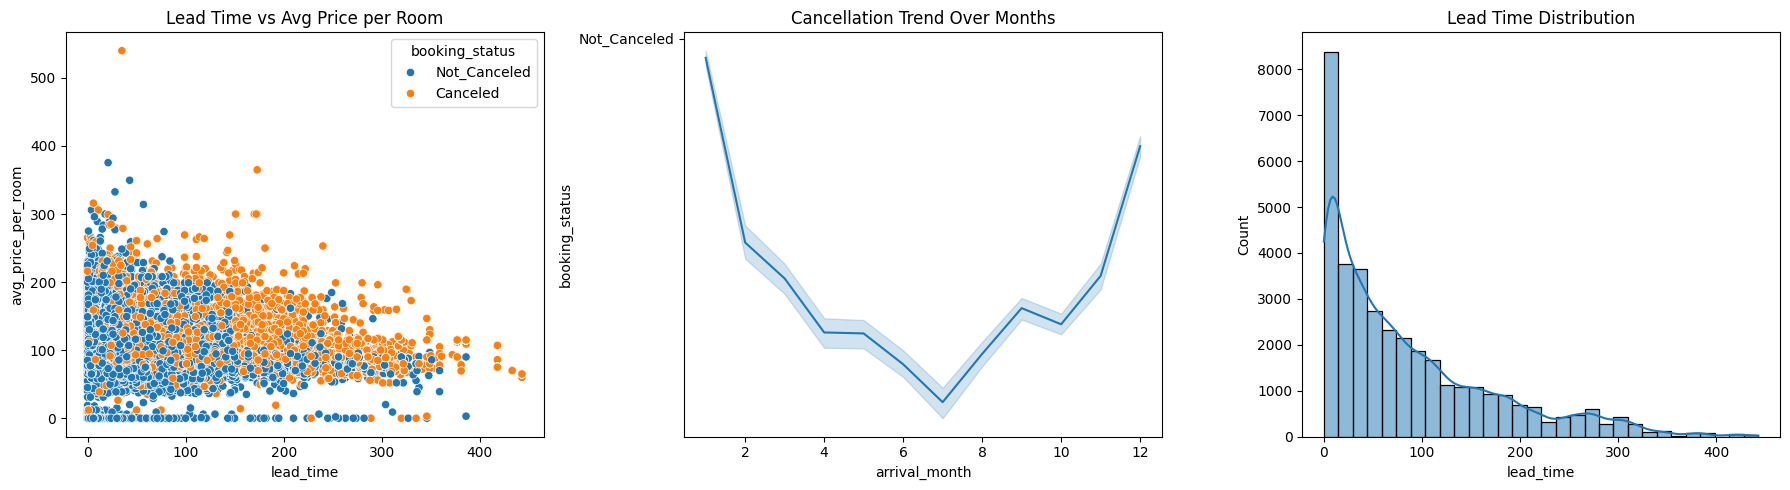


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90      4839
           1       0.81      0.75      0.78      2416

    accuracy                           0.86      7255
   macro avg       0.85      0.83      0.84      7255
weighted avg       0.86      0.86      0.86      7255

Accuracy Score: 0.8596829772570641


In [6]:
#Khush Pithva
#Priyansh Patel
#24BCE174
#24BCE180

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
df = pd.read_csv("Hotel Reservations.csv")

# Display dataset information
df.info()
print("\nUnique Values Per Column:\n", df.nunique())


# Data Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter Plot: Lead Time vs Avg Price per Room
sns.scatterplot(x=df['lead_time'], y=df['avg_price_per_room'], hue=df['booking_status'], ax=axes[0])
axes[0].set_title("Lead Time vs Avg Price per Room")

# Line Graph: Cancellations per Month
sns.lineplot(x=df['arrival_month'], y=df['booking_status'], estimator='mean', ax=axes[1])
axes[1].set_title("Cancellation Trend Over Months")

# Histogram: Lead Time Distribution
sns.histplot(df['lead_time'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Lead Time Distribution")

plt.tight_layout()
plt.show()

# Selecting Features and Target Variable
X = df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
        'no_of_week_nights', 'required_car_parking_space', 'lead_time',
        'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
        'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
        'avg_price_per_room', 'no_of_special_requests']]

y = df['booking_status'].map({"Not_Canceled": 0, "Canceled": 1})

# Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizing Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training KNN Model
knn = KNeighborsClassifier(n_neighbors=6, metric='manhattan', weights='distance')
knn.fit(X_train_scaled, y_train)

# Predicting and Evaluating
y_pred = knn.predict(X_test_scaled)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

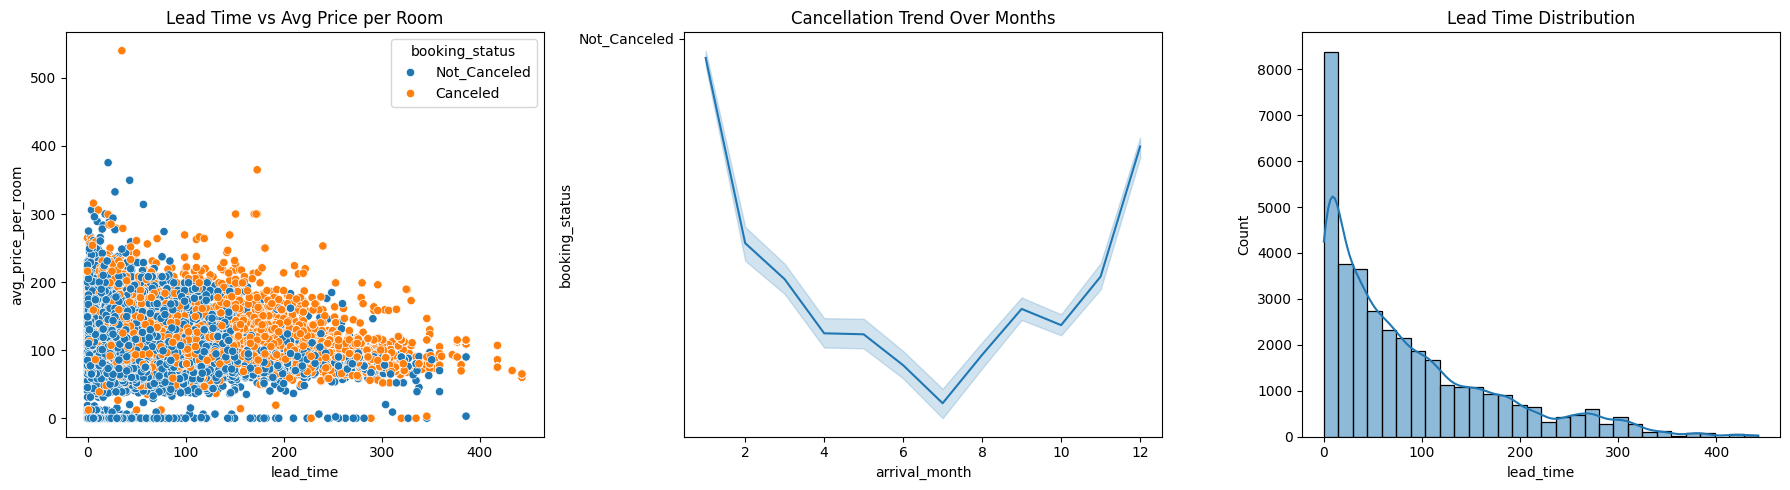


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90      4839
           1       0.81      0.75      0.78      2416

    accuracy                           0.86      7255
   macro avg       0.85      0.83      0.84      7255
weighted avg       0.86      0.86      0.86      7255

Accuracy Score: 0.8596829772570641


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv("Hotel Reservations.csv")

# Display dataset information
df.info()
print("\nUnique Values Per Column:\n", df.nunique())

# Display Descriptive Statistics
print("\nDescriptive Statistics of the Dataset:\n", df.describe())


# Data Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter Plot: Lead Time vs Avg Price per Room
sns.scatterplot(x=df['lead_time'], y=df['avg_price_per_room'], hue=df['booking_status'], ax=axes[0])
axes[0].set_title("Lead Time vs Avg Price per Room")

# Line Graph: Cancellations per Month
sns.lineplot(x=df['arrival_month'], y=df['booking_status'], estimator='mean', ax=axes[1])
axes[1].set_title("Cancellation Trend Over Months")

# Histogram: Lead Time Distribution
sns.histplot(df['lead_time'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Lead Time Distribution")

plt.tight_layout()
plt.show()

# Selecting Features and Target Variable
X = df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
        'no_of_week_nights', 'required_car_parking_space', 'lead_time',
        'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
        'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
        'avg_price_per_room', 'no_of_special_requests']]

y = df['booking_status'].map({"Not_Canceled": 0, "Canceled": 1})

# Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizing Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training KNN Model
knn = KNeighborsClassifier(n_neighbors=6, metric='manhattan', weights='distance')
knn.fit(X_train_scaled, y_train)

# Predicting and Evaluating
y_pred = knn.predict(X_test_scaled)

# Print Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


# Additional Model Statistics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

